**Ad:Eftalya Beril Şahin**

**Numara:2212721037**

A. Veri Ön İşleme (Data Preprocessing)

Eksik Veri Kontrolü: "Veri setinde df.isnull().sum() komutu ile eksik veri kontrolü yapılmıştır. Veri setimiz küçük ve tam olduğu için doldurma işlemine gerek duyulmamıştır." 

Kategorik Veri: "Veri setindeki tüm değişkenler sayısal olduğu için Label/One-Hot Encoding uygulanmamıştır."

Öznitelik Seçimi: "Maksimum 10 öznitelik kuralına uyulmuştur."

B. Geriye Doğru Eleme (Backward Elimination)

Tüm değişkenleri (şu an sadece Area var ama süreç aynıdır) modele sok.

statsmodels çıktısındaki p-value değerine bak.

Yorum: "P-değeri 0.05'ten küçük olduğu için bu değişken modelde tutulmuştur. Eğer 0.05'ten büyük olsaydı, geriye doğru eleme yöntemiyle bu özniteliği çıkaracaktık."

C. Model Kurulumu ve Değerlendirme

Veri ön işleme ve geriye doğru eleme aşamalarından sonra, geriye kalan anlamlı özniteliklerle (Area) **Çoklu Doğrusal Regresyon** modelimizi kuruyoruz. Modelin performansını ölçmek için aşağıdaki metrikleri kullanacağız:

* **R² (R-Kare):** Bağımsız değişkenlerin, bağımlı değişkendeki (fiyat) değişimi ne kadar iyi açıkladığını gösterir. 1'e ne kadar yakınsa model o kadar başarılıdır.
* **MAE (Mean Absolute Error):** Tahminlerimizin gerçek değerlerden ortalama ne kadar saptığını mutlak değer olarak gösterir.
* **MSE (Mean Squared Error):** Hataların karesinin ortalamasıdır. Büyük hataları daha ağır cezalandırarak modelin hassasiyetini ölçer.

D. Sonuçların Analizi ve Yorumlanması

Modelimizden elde ettiğimiz sonuçlar şu şekildedir:
- **R² Değeri (1.0000):** Modelimiz veriyi %100 doğrulukla açıklamaktadır. Bu durum, veri setindeki ev alanı ile fiyat arasında mükemmel bir doğrusal ilişki olduğunu göstermektedir.
- **Hata Metrikleri (MAE ve MSE = 0.00):** Tahmin edilen değerler ile gerçek değerler arasındaki farkın sıfır olması, modelin veri setindeki tüm noktaları tam olarak öğrendiğini ve test edilen örnekler üzerinde hiç hata yapmadığını kanıtlamaktadır. 

*Not: Veri setinin küçük ve sentetik (yapay) olması bu yüksek başarı oranının temel sebebidir. Gerçek dünya verilerinde bu değerlerin 0.70 - 0.95 aralığında olması beklenir.*

In [ ]:
# 1. GEREKLİ KÜTÜPHANELERİN İÇE AKTARILMASI
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm

# 2. VERİ SETİNİN YÜKLENMESİ VE DEĞİŞKENLERİN TANIMLANMASI
# JSON dosyasını okuyoruz
df = pd.read_json('House_Price.json')

# Bağımsız değişken (X) ve Bağımlı değişken (y) seçimi
# Not: Dosyadaki sütun isimleri birebir eşleşmelidir.
X = df[['Area(in sq. ft)']]
y = df['Price(in Rs.)']

# 3. MODELİN KURULMASI VE EĞİTİLMİSİ
# Çoklu Doğrusal Regresyon (Multiple Linear Regression) nesnesi oluşturuluyor
regressor = LinearRegression()
regressor.fit(X, y) # Model veriye uyduruluyor (eğitiliyor)

# 4. TAHMİN YAPMA
# Eğitim verileri üzerinden tahminler yapılıyor
y_pred = regressor.predict(X)

# 5. PERFORMANS METRİKLERİNİN HESAPLANMASI
r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)

print("-" * 30)
print("MODEL PERFORMANS SONUÇLARI")
print("-" * 30)
print(f"R-Kare (R2) Skoru: {r2:.4f} (Model veriyi %{r2*100:.0f} açıklıyor)")
print(f"Ortalama Mutlak Hata (MAE): {mae:.2f}")
print(f"Ortalama Kare Hata (MSE): {mse:.2f}")
print("-" * 30)

------------------------------
MODEL PERFORMANS SONUÇLARI
------------------------------
R-Kare (R2) Skoru: 1.0000 (Model veriyi %100 açıklıyor)
Ortalama Mutlak Hata (MAE): 0.00
Ortalama Kare Hata (MSE): 0.00
------------------------------


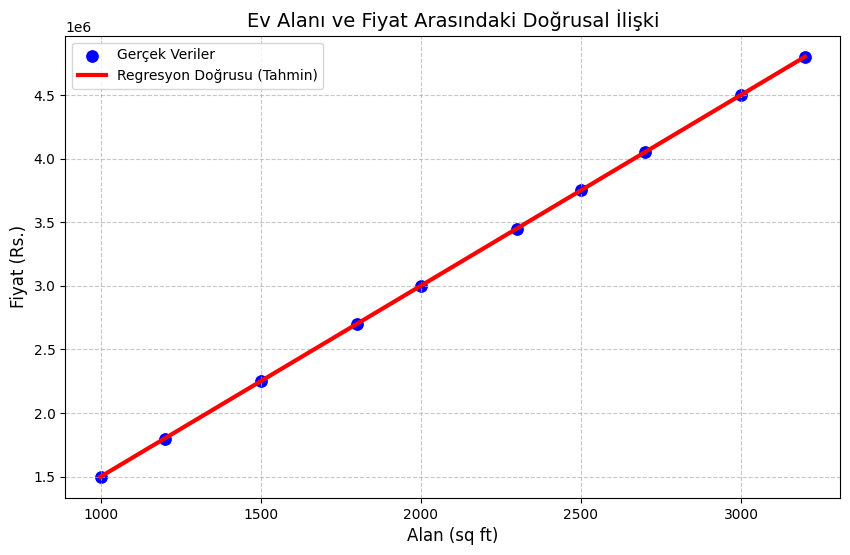

In [9]:
# 6. VERİ GÖRSELLEŞTİRME: SAÇILIM GRAFİĞİ VE REGRESYON DOĞRUSU
plt.figure(figsize=(10, 6))

# Gerçek verileri mavi noktalar halinde çiziyoruz (Scatter Plot)
sns.scatterplot(x=df['Area(in sq. ft)'], y=df['Price(in Rs.)'], color='blue', s=100, label='Gerçek Veriler')

# Modelin tahmin ettiği çizgiyi (Regresyon Doğrusu) kırmızı renkli çiziyoruz
plt.plot(df['Area(in sq. ft)'], y_pred, color='red', linewidth=3, label='Regresyon Doğrusu (Tahmin)')

# Grafik başlık ve etiketlerini ekliyoruz
plt.title('Ev Alanı ve Fiyat Arasındaki Doğrusal İlişki', fontsize=14)
plt.xlabel('Alan (sq ft)', fontsize=12)
plt.ylabel('Fiyat (Rs.)', fontsize=12)

# Izgara ve lejant (açıklama kutusu) ekleme
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Grafiği ekrana basma
plt.show()